# Praktikum Visi Komputer - FFT dan Noise Filtering

Praktikum ini mencakup:
1. Analisis domain frekuensi menggunakan FFT
2. Penambahan berbagai jenis noise pada citra
3. Perbandingan filter untuk menghilangkan noise

In [27]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from scipy.ndimage import gaussian_filter, median_filter
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (15, 12)

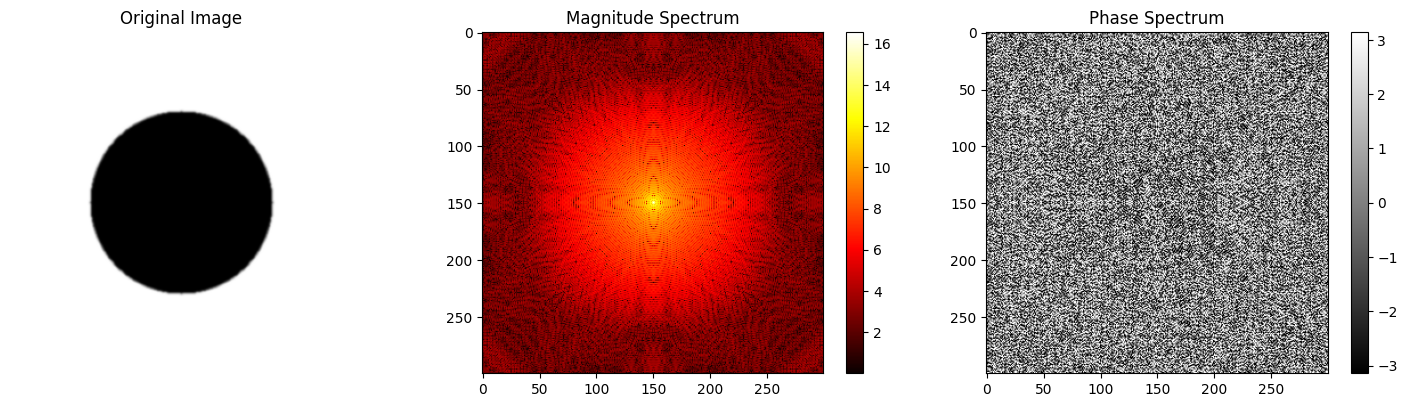

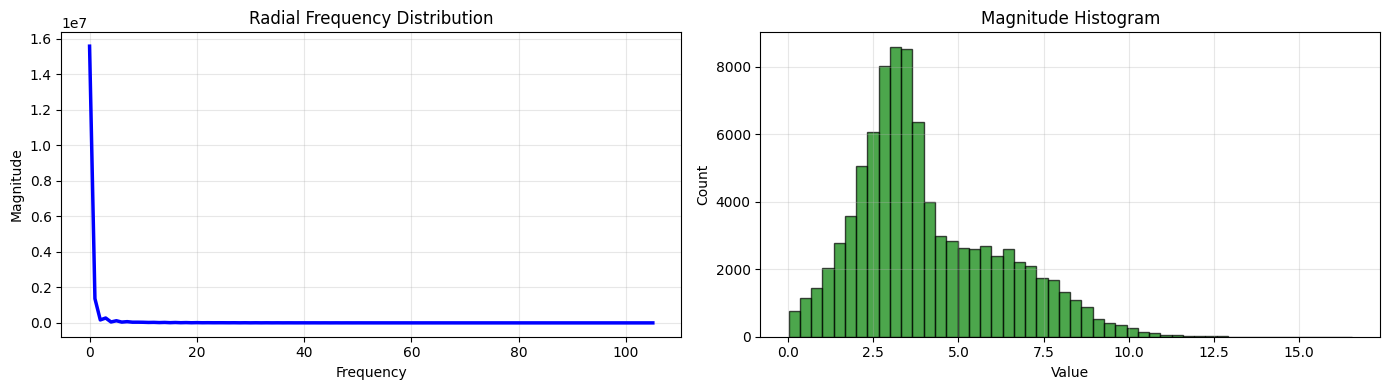

In [28]:
# BAGIAN 1 - Domain Frekuensi

# Smooth object image
def create_smooth_object_image():
    img = np.zeros((300, 300, 3), dtype=np.uint8)
    img[:, :] = (200, 200, 200)
    cv2.circle(img, (150, 150), 80, (50, 50, 150), -1)
    img_smooth = cv2.GaussianBlur(img, (5, 5), 0)
    return cv2.cvtColor(img_smooth, cv2.COLOR_BGR2GRAY)

img_fft = create_smooth_object_image()

# FFT computation
fft_img = np.fft.fft2(img_fft)
fft_shift = np.fft.fftshift(fft_img)
magnitude_spectrum = np.log1p(np.abs(fft_shift))
phase_spectrum = np.angle(fft_shift)

# Display FFT results
fig = plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plt.imshow(img_fft, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(magnitude_spectrum, cmap='hot')
plt.title('Magnitude Spectrum')
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(phase_spectrum, cmap='gray')
plt.title('Phase Spectrum')
plt.colorbar()
plt.tight_layout()
plt.show()

# Frequency distribution analysis
def analyze_frequency_distribution(fft_shift):
    H, W = fft_shift.shape
    Y, X = np.ogrid[:H, :W]
    center_y, center_x = H//2, W//2
    distance = np.sqrt((Y - center_y)**2 + (X - center_x)**2).astype(int)
    max_distance = int(np.sqrt(H**2 + W**2) / 2)
    freq_bins = np.zeros(max_distance)
    for d in range(max_distance):
        mask = distance == d
        if np.sum(mask) > 0:
            freq_bins[d] = np.mean(np.abs(fft_shift[mask]))
    return freq_bins

freq_bins = analyze_frequency_distribution(fft_shift)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(freq_bins[:len(freq_bins)//2], 'b-', linewidth=2.5)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('Radial Frequency Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(magnitude_spectrum.flatten(), bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Magnitude Histogram')
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

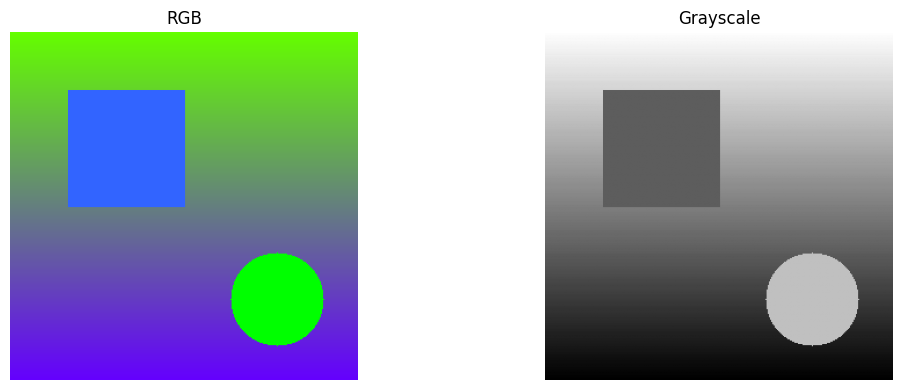

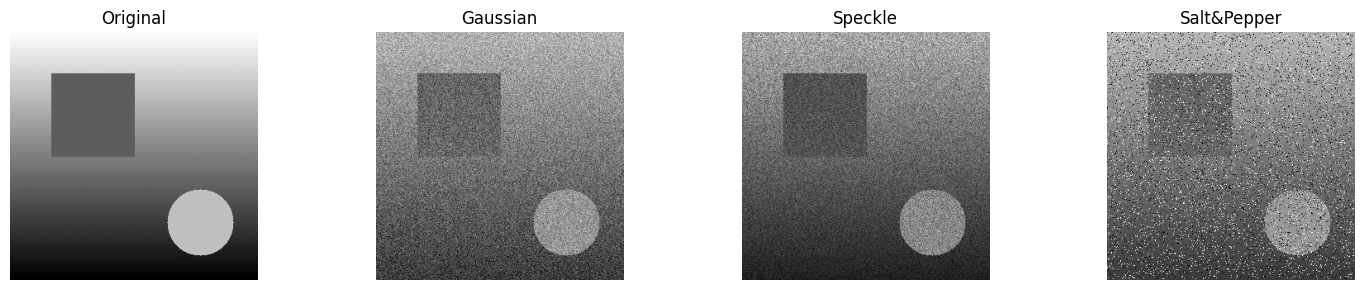

In [29]:
# BAGIAN 2 - Noise pada Citra

# RGB to Grayscale
def create_rgb_image():
    img = np.zeros((300, 300, 3), dtype=np.uint8)
    for i in range(300):
        img[i, :, 0] = int((i/300) * 255)
        img[i, :, 1] = int(((300-i)/300) * 255)
        img[i, :, 2] = 100
    cv2.rectangle(img, (50, 50), (150, 150), (255, 100, 50), -1)
    cv2.circle(img, (230, 230), 40, (0, 255, 0), -1)
    return img

img_rgb = create_rgb_image()
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
img_rgb_display = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB)
axes[0].imshow(img_rgb_display)
axes[0].set_title('RGB')
axes[0].axis('off')
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Grayscale')
axes[1].axis('off')
plt.tight_layout()
plt.show()

original_image = img_gray.copy().astype(np.float32)

# Add noise functions
def add_gaussian_noise(image, mean=0, std=25):
    noise = np.random.normal(mean, std, image.shape)
    noisy_image = image + noise
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_speckle_noise(image, prob=0.1):
    speckle = np.random.normal(1, prob, image.shape)
    noisy_image = image * speckle
    return np.clip(noisy_image, 0, 255).astype(np.uint8)

def add_salt_pepper_noise(image, prob=0.05):
    noisy_image = image.copy()
    num_salt = np.ceil(prob/2 * image.size)
    coords_salt = [np.random.randint(0, i-1, int(num_salt)) for i in image.shape]
    noisy_image[tuple(coords_salt)] = 255
    num_pepper = np.ceil(prob/2 * image.size)
    coords_pepper = [np.random.randint(0, i-1, int(num_pepper)) for i in image.shape]
    noisy_image[tuple(coords_pepper)] = 0
    return noisy_image.astype(np.uint8)

# Generate noise
img_gaussian_noise = add_gaussian_noise(img_gray.astype(np.float32), mean=0, std=25)
img_speckle_noise = add_speckle_noise(img_gray.astype(np.float32), prob=0.15)
img_salt_pepper_noise = add_salt_pepper_noise(img_gray.astype(np.float32), prob=0.1)

# Display noise
fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.imshow(img_gray, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_gaussian_noise, cmap='gray')
plt.title('Gaussian')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_speckle_noise, cmap='gray')
plt.title('Speckle')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_salt_pepper_noise, cmap='gray')
plt.title('Salt&Pepper')
plt.axis('off')
plt.tight_layout()
plt.show()

Gaussian Noise:
Mean: 33.07, Gaussian: 30.69, Median: 31.73


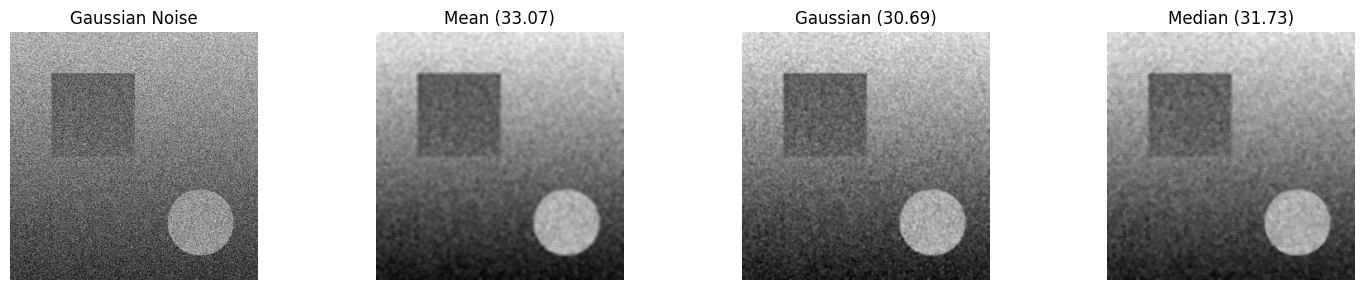

Speckle Noise:
Mean: 34.71, Gaussian: 32.88, Median: 33.96


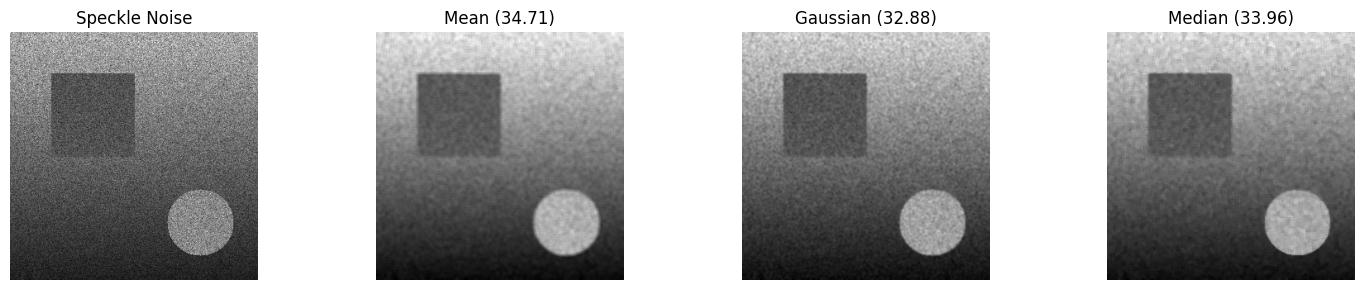

Salt & Pepper Noise:
Mean: 28.86, Gaussian: 26.34, Median: 45.96


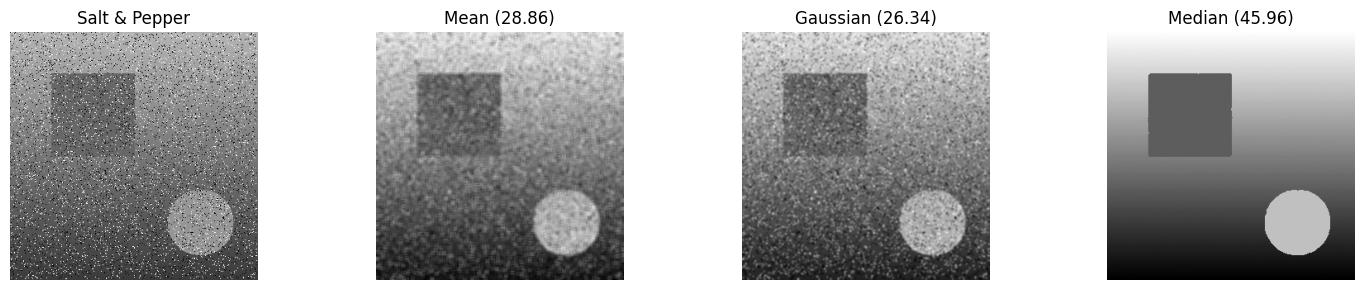

Results:
    Noise Type    Filter       PSNR
0     Gaussian      Mean  33.070454
1     Gaussian  Gaussian  30.693438
2     Gaussian    Median  31.727373
3      Speckle      Mean  34.708408
4      Speckle  Gaussian  32.877476
5      Speckle    Median  33.962563
6  Salt&Pepper      Mean  28.855715
7  Salt&Pepper  Gaussian  26.342987
8  Salt&Pepper    Median  45.961411


In [30]:
# BAGIAN 3 - Penerapan Filtering pada Citra

# Filter functions
def apply_mean_filter(image, kernel_size=5):
    return cv2.blur(image, (kernel_size, kernel_size))

def apply_gaussian_filter(image, kernel_size=5, sigma=1.0):
    return cv2.GaussianBlur(image, (kernel_size, kernel_size), sigma)

def apply_median_filter(image, kernel_size=5):
    return cv2.medianBlur(image, kernel_size)

# PSNR function
def calculate_psnr(original, filtered):
    if filtered.shape != original.shape:
        return 0
    mse = np.mean((original.astype(np.float32) - filtered.astype(np.float32))**2)
    if mse == 0:
        return 100
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr

# Gaussian Noise
print("Gaussian Noise:")
img_g_mean = apply_mean_filter(img_gaussian_noise)
img_g_gaussian = apply_gaussian_filter(img_gaussian_noise)
img_g_median = apply_median_filter(img_gaussian_noise)

psnr_g_mean = calculate_psnr(img_gray, img_g_mean)
psnr_g_gaussian = calculate_psnr(img_gray, img_g_gaussian)
psnr_g_median = calculate_psnr(img_gray, img_g_median)

print(f"Mean: {psnr_g_mean:.2f}, Gaussian: {psnr_g_gaussian:.2f}, Median: {psnr_g_median:.2f}")

fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.imshow(img_gaussian_noise, cmap='gray')
plt.title('Gaussian Noise')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_g_mean, cmap='gray')
plt.title(f'Mean ({psnr_g_mean:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_g_gaussian, cmap='gray')
plt.title(f'Gaussian ({psnr_g_gaussian:.2f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_g_median, cmap='gray')
plt.title(f'Median ({psnr_g_median:.2f})')
plt.axis('off')
plt.tight_layout()
plt.show()

# Speckle Noise
print("Speckle Noise:")
img_s_mean = apply_mean_filter(img_speckle_noise)
img_s_gaussian = apply_gaussian_filter(img_speckle_noise)
img_s_median = apply_median_filter(img_speckle_noise)

psnr_s_mean = calculate_psnr(img_gray, img_s_mean)
psnr_s_gaussian = calculate_psnr(img_gray, img_s_gaussian)
psnr_s_median = calculate_psnr(img_gray, img_s_median)

print(f"Mean: {psnr_s_mean:.2f}, Gaussian: {psnr_s_gaussian:.2f}, Median: {psnr_s_median:.2f}")

fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.imshow(img_speckle_noise, cmap='gray')
plt.title('Speckle Noise')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_s_mean, cmap='gray')
plt.title(f'Mean ({psnr_s_mean:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_s_gaussian, cmap='gray')
plt.title(f'Gaussian ({psnr_s_gaussian:.2f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_s_median, cmap='gray')
plt.title(f'Median ({psnr_s_median:.2f})')
plt.axis('off')
plt.tight_layout()
plt.show()

# Salt & Pepper Noise
print("Salt & Pepper Noise:")
img_sp_mean = apply_mean_filter(img_salt_pepper_noise)
img_sp_gaussian = apply_gaussian_filter(img_salt_pepper_noise)
img_sp_median = apply_median_filter(img_salt_pepper_noise)

psnr_sp_mean = calculate_psnr(img_gray, img_sp_mean)
psnr_sp_gaussian = calculate_psnr(img_gray, img_sp_gaussian)
psnr_sp_median = calculate_psnr(img_gray, img_sp_median)

print(f"Mean: {psnr_sp_mean:.2f}, Gaussian: {psnr_sp_gaussian:.2f}, Median: {psnr_sp_median:.2f}")

fig = plt.figure(figsize=(15, 3))
plt.subplot(1, 4, 1)
plt.imshow(img_salt_pepper_noise, cmap='gray')
plt.title('Salt & Pepper')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(img_sp_mean, cmap='gray')
plt.title(f'Mean ({psnr_sp_mean:.2f})')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(img_sp_gaussian, cmap='gray')
plt.title(f'Gaussian ({psnr_sp_gaussian:.2f})')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(img_sp_median, cmap='gray')
plt.title(f'Median ({psnr_sp_median:.2f})')
plt.axis('off')
plt.tight_layout()
plt.show()

# Results
print("Results:")
results = pd.DataFrame({
    'Noise Type': ['Gaussian', 'Gaussian', 'Gaussian', 'Speckle', 'Speckle', 'Speckle', 'Salt&Pepper', 'Salt&Pepper', 'Salt&Pepper'],
    'Filter': ['Mean', 'Gaussian', 'Median', 'Mean', 'Gaussian', 'Median', 'Mean', 'Gaussian', 'Median'],
    'PSNR': [psnr_g_mean, psnr_g_gaussian, psnr_g_median, psnr_s_mean, psnr_s_gaussian, psnr_s_median, psnr_sp_mean, psnr_sp_gaussian, psnr_sp_median]
})
print(results)